# 📊 Customer Behavior & Sales Insights — Olist E-commerce

## ❓ Main Question
How do customers behave, and what drives revenue growth in this e-commerce business?

---

## 🎯 Objectives
- Understand sales trends over time  
- Identify top-performing product categories  
- Analyze customer behavior (new vs repeat)  
- Discover revenue concentration (Pareto principle)  
- Generate business recommendations  

---

## 📂 Dataset
This project uses the Olist Brazilian E-commerce dataset, which contains:
- Orders
- Customers
- Products
- Payments
- Sellers

---

## 🧠 Approach
We will:
1. Clean and merge multiple datasets  
2. Create a unified analysis table  
3. Explore patterns using data analysis  
4. Interpret results from a business perspective  

In [3]:
# =========================
# IMPORT LIBRARIES
# =========================

# pandas: for data manipulation and analysis
import pandas as pd

# numpy: for numerical operations
import numpy as np

# matplotlib & seaborn: for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for better readability
sns.set(style="whitegrid")

# =========================
# LOAD DATASETS
# =========================

# Each dataset represents a part of the business process

customers = pd.read_csv(r"E:\Document\E-Commerce\archive\olist_customers_dataset.csv")
orders = pd.read_csv(r"E:\Document\E-Commerce\archive\olist_orders_dataset.csv")
order_items = pd.read_csv(r"E:\Document\E-Commerce\archive\olist_order_items_dataset.csv")
payments = pd.read_csv(r"E:\Document\E-Commerce\archive\olist_order_payments_dataset.csv")
products = pd.read_csv(r"E:\Document\E-Commerce\archive\olist_products_dataset.csv")
category_translation = pd.read_csv(r"E:\Document\E-Commerce\archive\product_category_name_translation.csv")

# Why we load all:
# We need to combine them to build a full picture of:
# Customer → Order → Product → Payment

In [4]:
# =========================
# UNDERSTAND DATA STRUCTURE
# =========================

# Check first rows
orders.head()

# Check columns and types
orders.info()

# Check missing values
orders.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

## 🔍 What are we checking?

- Structure of the dataset  
- Missing values  
- Data types  

This helps us understand:
- What needs cleaning  
- What features we can use  

In [5]:
# =========================
# MERGE DATASETS
# =========================

# Step 1: Merge orders with customers
df = orders.merge(customers, on="customer_id", how="left")

# Why:
# Each order belongs to a customer → we need customer info

# Step 2: Merge with order items
df = df.merge(order_items, on="order_id", how="left")

# Why:
# Each order can have multiple items → revenue comes from items

# Step 3: Merge with payments
df = df.merge(payments, on="order_id", how="left")

# Why:
# Payment value tells us actual revenue

# Step 4: Merge with products
df = df.merge(products, on="product_id", how="left")

# Step 5: Add category names (translated)
df = df.merge(category_translation,
              on="product_category_name",
              how="left")

df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,payment_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,18.12,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,2.00,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,18.59,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,141.46,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,179.12,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto


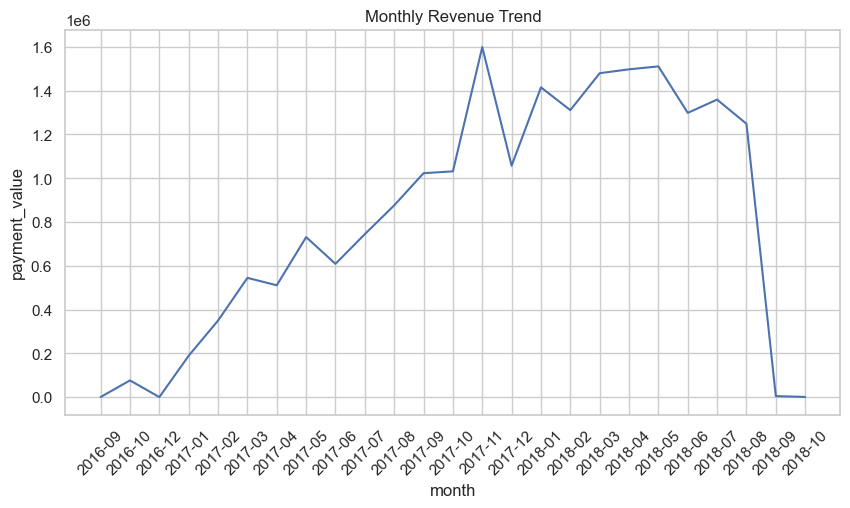

In [6]:
# Convert date column to datetime
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])

# Extract month
df["month"] = df["order_purchase_timestamp"].dt.to_period("M")

# Calculate monthly revenue
monthly_sales = df.groupby("month")["payment_value"].sum().reset_index()

# Convert month to string for plotting
monthly_sales["month"] = monthly_sales["month"].astype(str)

# Plot
plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_sales, x="month", y="payment_value")
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.show()

### 📈 Insight

Revenue shows growth over time, indicating increasing demand.

### 💡 Business Meaning

- Marketing or platform adoption is working  
- Growth is likely driven by increasing orders  

### 🚀 Recommendation

- Continue scaling acquisition channels  
- Prepare operations for higher demand  

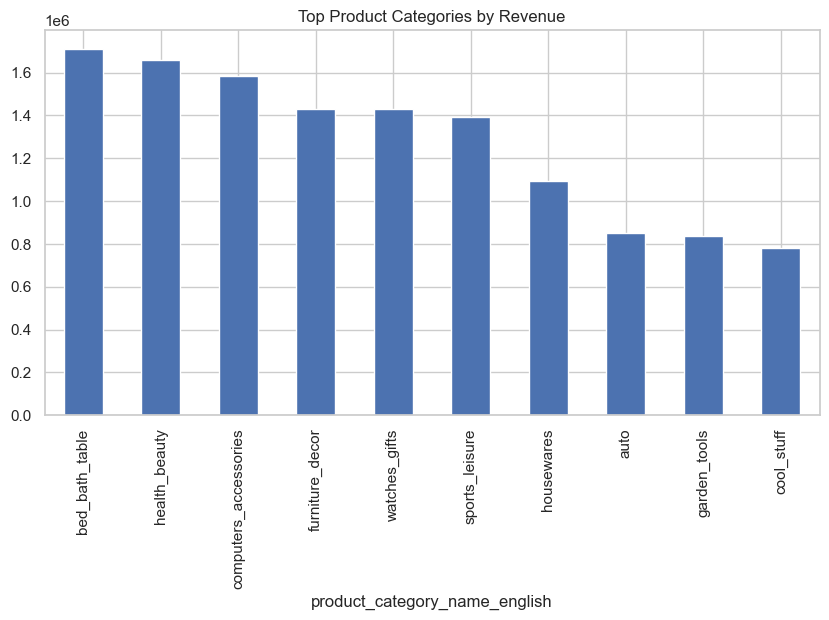

In [7]:
category_sales = df.groupby("product_category_name_english")["payment_value"].sum()

top_categories = category_sales.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_categories.plot(kind="bar")
plt.title("Top Product Categories by Revenue")
plt.show()

In [8]:
# Count number of orders per customer
customer_orders = df.groupby("customer_unique_id")["order_id"].nunique()

# Count distribution
customer_distribution = customer_orders.value_counts()

customer_distribution.head()

order_id
1    93099
2     2745
3      203
4       30
5        8
Name: count, dtype: int64

Most customers purchase only once.

### 💡 Meaning:
Retention is weak → business relies on new customers

### 🚀 Strategy:
- Improve customer retention
- Add loyalty programs
- Encourage second purchase

In [9]:
customer_revenue = df.groupby("customer_unique_id")["payment_value"].sum()

# Sort customers by revenue
customer_revenue = customer_revenue.sort_values(ascending=False)

# Calculate cumulative percentage
cum_revenue = customer_revenue.cumsum() / customer_revenue.sum()

cum_revenue.head()

customer_unique_id
0a0a92112bd4c708ca5fde585afaa872    0.005340
698e1cf81d01a3d389d96145f7fa6df8    0.007551
c402f431464c72e27330a67f7b94d4fb    0.009702
4007669dec559734d6f53e029e360987    0.011485
ef8d54b3797ea4db1d63f0ced6a906e9    0.012960
Name: payment_value, dtype: float64

A small percentage of customers generate a large portion of revenue.

### 💡 Meaning:
This business follows the Pareto principle

### 🚀 Strategy:
- Focus on high-value customers
- Create VIP programs
- Personalize offers